In [1]:
pip install numpy matplotlib pygame

Note: you may need to restart the kernel to use updated packages.


Scenario 1: Simple 2D Robot Motion

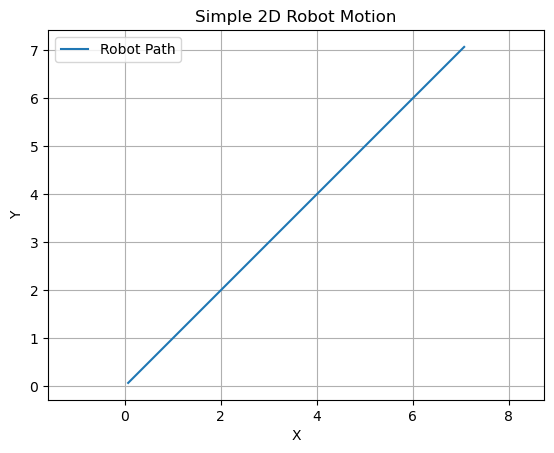

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x, y = 0, 0
theta = np.pi / 4  # 45 degrees
v = 1  # velocity
time = np.linspace(0, 10, 100)

x_path, y_path = [], []

for t in time:
    x += v * np.cos(theta) * 0.1
    y += v * np.sin(theta) * 0.1
    x_path.append(x)
    y_path.append(y)

plt.plot(x_path, y_path, label='Robot Path')
plt.title('Simple 2D Robot Motion')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


Scenario 2: Obstacle Avoidance

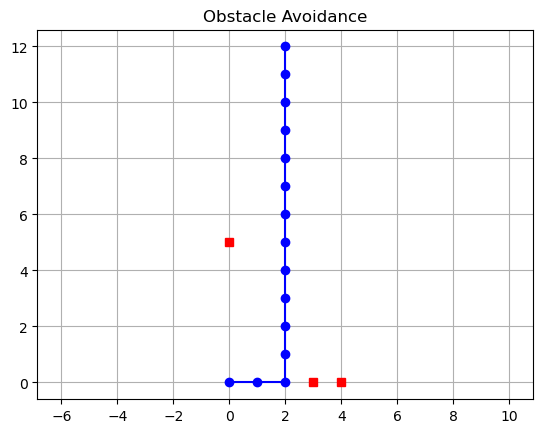

In [3]:
import matplotlib.pyplot as plt

x, y = [0], [0]
directions = [(1, 0), (0, 1), (-1, 0), (0, -1)]  # Right, Up, Left, Down
dir_index = 0
obstacles = {(3, 0), (4, 0), (0, 5)}

for _ in range(15):
    next_x = x[-1] + directions[dir_index][0]
    next_y = y[-1] + directions[dir_index][1]
    
    if (next_x, next_y) in obstacles:
        dir_index = (dir_index + 1) % 4  # Turn right
        continue
    x.append(next_x)
    y.append(next_y)

for ox, oy in obstacles:
    plt.plot(ox, oy, 'rs')  # obstacle

plt.plot(x, y, 'bo-')
plt.title('Obstacle Avoidance')
plt.grid(True)
plt.axis('equal')
plt.show()


Scenario 3: Line Following using PID Controller

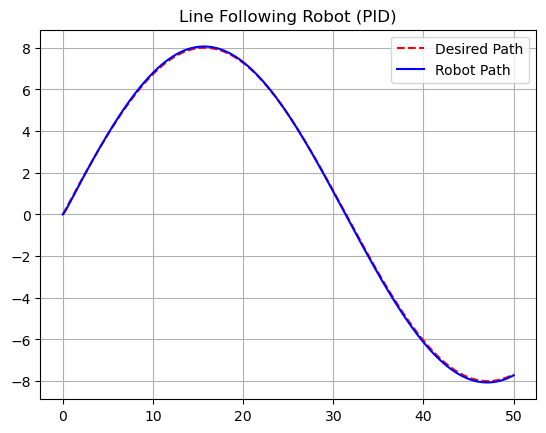

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Desired path
x = np.linspace(0, 50, 500)
y_desired = 8 * np.sin(0.1 * x)

# PID Controller parameters
Kp = 0.5
Ki = 0.01
Kd = 0.1

y_robot = 0
y_path = []
error_sum = 0
prev_error = 0

for i in range(len(x)):
    error = y_desired[i] - y_robot
    error_sum += error
    derivative = error - prev_error
    y_robot += Kp * error + Ki * error_sum + Kd * derivative
    prev_error = error
    y_path.append(y_robot)

plt.plot(x, y_desired, 'r--', label="Desired Path")
plt.plot(x, y_path, 'b-', label="Robot Path")
plt.legend()
plt.title("Line Following Robot (PID)")
plt.grid(True)
plt.show()


Scenario 4: Path Planning with A*

In [5]:
import heapq

grid = [[0, 0, 0, 1, 0],
        [1, 1, 0, 1, 0],
        [0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1],
        [0, 0, 0, 0, 0]]

start = (0, 0)
goal = (4, 4)

def heuristic(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def a_star(grid, start, goal):
    open_list = []
    heapq.heappush(open_list, (0 + heuristic(start, goal), 0, start, []))
    visited = set()

    while open_list:
        _, cost, current, path = heapq.heappop(open_list)
        if current in visited:
            continue
        visited.add(current)
        path = path + [current]

        if current == goal:
            return path

        for dx, dy in [(0,1), (1,0), (-1,0), (0,-1)]:
            nx, ny = current[0] + dx, current[1] + dy
            if 0 <= nx < len(grid) and 0 <= ny < len(grid[0]):
                if grid[nx][ny] == 0:
                    heapq.heappush(open_list, (
                        cost + 1 + heuristic((nx, ny), goal),
                        cost + 1, (nx, ny), path))
    return []

path = a_star(grid, start, goal)

for i in range(len(grid)):
    for j in range(len(grid[0])):
        if (i, j) == start:
            print("S", end=" ")
        elif (i, j) == goal:
            print("G", end=" ")
        elif (i, j) in path:
            print("*", end=" ")
        elif grid[i][j] == 1:
            print("#", end=" ")
        else:
            print(".", end=" ")
    print()


S * * # . 
# # * # . 
* * * . . 
* # # # # 
* * * * G 


Scenario 5: Two Robots Avoiding Collision

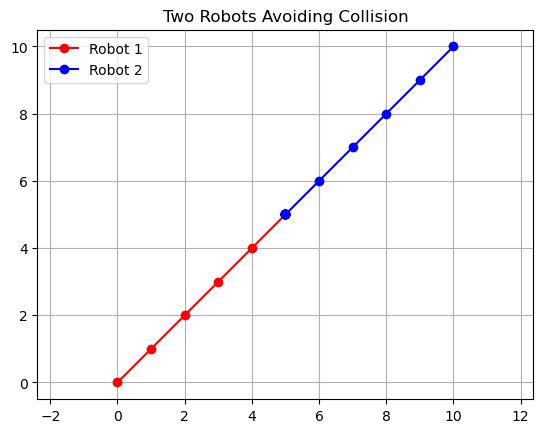

In [6]:
import matplotlib.pyplot as plt

robot1 = [[0, 0]]
robot2 = [[10, 10]]

for _ in range(20):
    r1 = robot1[-1]
    r2 = robot2[-1]
    
    # Simple rule: move towards each other
    dx1 = 1 if r1[0] < r2[0] else -1
    dy1 = 1 if r1[1] < r2[1] else -1
    
    dx2 = -dx1
    dy2 = -dy1

    # Collision avoidance
    if abs(r1[0] - r2[0]) <= 1 and abs(r1[1] - r2[1]) <= 1:
        dx1 = dy1 = dx2 = dy2 = 0

    robot1.append([r1[0] + dx1, r1[1] + dy1])
    robot2.append([r2[0] + dx2, r2[1] + dy2])

robot1 = list(zip(*robot1))
robot2 = list(zip(*robot2))

plt.plot(*robot1, 'r-o', label='Robot 1')
plt.plot(*robot2, 'b-o', label='Robot 2')
plt.title('Two Robots Avoiding Collision')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


Scenario 6: 2-Link Planar Arm 

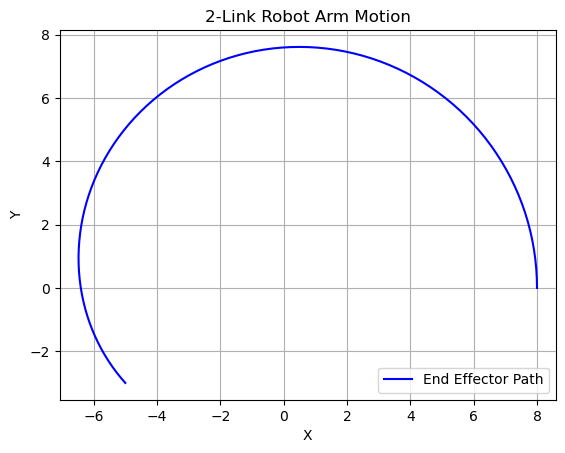

In [7]:
import numpy as np
import matplotlib.pyplot as plt

l1, l2 = 5, 3
theta1_range = np.linspace(0, np.pi, 100)
theta2_range = np.linspace(0, np.pi/2, 100)

x1, y1 = [], []
x2, y2 = [], []

for t1, t2 in zip(theta1_range, theta2_range):
    x_elbow = l1 * np.cos(t1)
    y_elbow = l1 * np.sin(t1)
    x_tip = x_elbow + l2 * np.cos(t1 + t2)
    y_tip = y_elbow + l2 * np.sin(t1 + t2)
    
    x1.append(x_elbow)
    y1.append(y_elbow)
    x2.append(x_tip)
    y2.append(y_tip)

plt.plot(x2, y2, 'b-', label='End Effector Path')
plt.title('2-Link Robot Arm Motion')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()



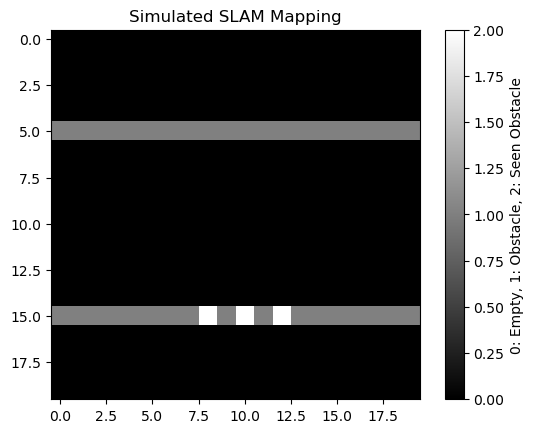

In [8]:
import numpy as np
import matplotlib.pyplot as plt

grid = np.zeros((20, 20))
robot_pos = [10, 10]
directions = [(0,1), (1,0), (0,-1), (-1,0)]

# Simulated map obstacles
for i in range(20):
    grid[5][i] = 1
    grid[15][i] = 1

# Simulate movement and mapping
for _ in range(10):
    for dx, dy in directions:
        scan_x = robot_pos[0] + dx * 2
        scan_y = robot_pos[1] + dy * 2
        if 0 <= scan_x < 20 and 0 <= scan_y < 20:
            if grid[scan_x][scan_y] == 1:
                grid[scan_x][scan_y] = 2  # mark as seen obstacle
    robot_pos[0] += 1

plt.imshow(grid, cmap='gray')
plt.title('Simulated SLAM Mapping')
plt.colorbar(label='0: Empty, 1: Obstacle, 2: Seen Obstacle')
plt.show()


Scenario 8: Wall Avoidance via Reinforcement Learning (Q-Learning)

In [9]:
import numpy as np
import random

actions = ['up', 'down', 'left', 'right']
grid = np.zeros((5, 5))
grid[1][1] = grid[1][2] = grid[1][3] = -1  # walls
q_table = np.zeros((5, 5, 4))
alpha, gamma, episodes = 0.1, 0.9, 100

def choose_action(state):
    if random.random() < 0.2:
        return random.randint(0, 3)
    return np.argmax(q_table[state[0], state[1]])

for _ in range(episodes):
    pos = [0, 0]
    for _ in range(50):
        action = choose_action(pos)
        new_pos = pos.copy()
        if actions[action] == 'up': new_pos[0] -= 1
        elif actions[action] == 'down': new_pos[0] += 1
        elif actions[action] == 'left': new_pos[1] -= 1
        elif actions[action] == 'right': new_pos[1] += 1

        if not (0 <= new_pos[0] < 5 and 0 <= new_pos[1] < 5):
            reward = -5
            new_pos = pos
        elif grid[new_pos[0]][new_pos[1]] == -1:
            reward = -10
            new_pos = pos
        else:
            reward = 1

        best_next = np.max(q_table[new_pos[0], new_pos[1]])
        q_table[pos[0], pos[1], action] += alpha * (reward + gamma * best_next - q_table[pos[0], pos[1], action])
        pos = new_pos

print("Q-learning finished. Final Q-values:")
print(np.round(np.max(q_table, axis=2), 2))


Q-learning finished. Final Q-values:
[[10.   10.   10.   10.    1.9 ]
 [ 6.47  0.    0.    0.    0.  ]
 [ 0.46  0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.    0.  ]]
